### Lecture Notes: Sampling, Models and Statistic

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html)

**Recommended Readings:**
- [Sampling](https://www.inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html)
- [Distribution of a Statistic](https://www.inferentialthinking.com/chapters/10/3/Empirical_Distribution_of_a_Statistic.html)
- [Random Sampling in Python](https://www.inferentialthinking.com/chapters/10/4/Random_Sampling_in_Python.html)

In [1]:
# import modules to be used in this notebook

from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')


## Finding Probability ##

The textbook explains 3 rules of finding probability.

1. **Complement Rule**: classify an event happening and not happening, like true/false questions in an exam

   P(event A doesn't happen) = 1 - (event A happened)


3. **Addition Rule**: pick an option from a pool of multiple options, like MC questions in an exam

   P(event A or event B happens) = P(event A happens) + P(event B happens) - P(event A and event B both happen)
   
5. **Multiplication Rule**: something must happens in a certain order or sequence, like logical procedure questions where the answer to the second question relies on the answer of the first question

   P(two events both happen) = P(one event happens) × P(the other event happens, given that the first one happened)

## Sampling ##

### Deterministic Samples ###

When we specify certain data points in a dataset to be selected in a sampling, we call them deterministic samples. No chance involved.

### Probabilistic Samples (Ramdom Samples) ###

The probabilistic samples are the opposite where all elements have a chance to be chosen. But the elements may or may have the same chance of being chosen. Some may have higher chance and other may have lower, depending on sampling scheme.

For example, in clinical trials/experiments, patients who have certain profiles may have a higher chance to be selected.

`np.random.choice(array)` can be used of probabilistic sampling. 

### Systematic Samples ###

A scheme that is used to select samples from a dataset. Elements in the dataset may or may not have the equal chance of being selected. But the initial starting point must be chosen by chance that means each element in the dataset has an equal opportunity of being selected. Then the rest of the samples will be chosen based on the initial starting point.

We also sometimes call it systematic random sampling.

### With or Without Replacement ###

It is about how we handle the elements after they are drawn from a dataset. Very straight forward.

With replacement, we put them back to the dataset. So they may be chosen again.

Without replacement, we don't put them back to the dataset. So they won't be chose again.

`np.random.choice(array, n, replace=True)` has an argument to set with and without replacement.

### Convenience Samples ###

A convenience sample is a deterministic sample and biased, not a random sample. 


### Sampling tables (from a population)

Similar to `np.random.choice()`, `tbl.sample()` can also be used to draw samples with or without replacement.

##### Notes:
`np.random.choice()` returns an array

`tbl.sample()` returns a table


In [2]:
students = Table().read_table('student_data.csv')
students

SEX,COLOR,ZIP,MATH,PAPER,CAR,SHOE,AGE,HEIGHT,PETS,SOCIAL
Female,Blue,95403,3,2,2018,6.5,20,61,0,Yes
Female,Other,95401,2,5,2007,6.5,26,61,1,No
Female,Green,95492,1,3,1994,5.5,22,62,4,Yes
Female,Black,95472,3,3,nan,8,19,62,2,Yes
Female,Purple,95409,2,2,1990,7,19,63,3,Yes
Female,Orange,95407,4,3,2016,8.5,37,63,2,Yes
Female,Blue,95401,5,4,2003,8,17,63,5,Yes
Female,Blue,94928,3,3,2012,7.5,18,63,6,Yes
Female,Purple,95403,4,5,nan,8.5,36,63,0,No
Female,Red,95404,2,2,2011,7.5,20,64,7,Yes


### Simple Random Sample (SRS)

1. Everyone in a data pool has the same chance to be selected
2. Each selection is independent, not influenced by anyone in the data pool

#### Use `tbl.sample()`

In [3]:
# simple random sampling (SRS) with replacement
# SRS means all possible samples have the same chance of being taken

students.sample(5)

SEX,COLOR,ZIP,MATH,PAPER,CAR,SHOE,AGE,HEIGHT,PETS,SOCIAL
Female,Red,94558,3,3,2016,9,22,67,3,No
Male,Blue,95401,2,2,2002,11.5,23,74,3,Yes
Female,Green,95403,3,3,nan,8,17,66,1,No
Male,Red,95492,3,3,1999,8,18,65,1,Yes
Female,Blue,95405,1,5,nan,10,23,67,4,Yes


#### Use `np.random.choice()` 

In [4]:
# sampling the table using np.random.choice()
# np.random.choice() returns an array, we need to tbl.take() to creat a table view

# create an array of integers from 0 to number of students minus 1
sample_array = np.arange(students.num_rows)
students.take(np.random.choice(sample_array, 5))

# Or

#students.take(np.random.choice(np.arange(students.num_rows), 5))

SEX,COLOR,ZIP,MATH,PAPER,CAR,SHOE,AGE,HEIGHT,PETS,SOCIAL
Male,Orange,95407,3,2,2005,8,22,68,0,Yes
Female,Purple,95409,2,2,1990,7,19,63,3,Yes
Male,Purple,95404,3,2,nan,10.5,20,70,0,No
Male,Yellow,94928,3,3,2014,10.5,26,70,2,Yes
Female,Blue,94928,3,3,2012,7.5,18,63,6,Yes


#### Simple Random Sample with and without replacement

By default, both `tbl.sample()` and `np.random.choice()` are with replacement. For without replacement, it must be explicitly indicated in the parameter list.

In [5]:
# tbl.sample() sampling without replacement 
students.sample(5, with_replacement=False)

SEX,COLOR,ZIP,MATH,PAPER,CAR,SHOE,AGE,HEIGHT,PETS,SOCIAL
Male,Green,94928,1,2,2007,10,30,74,1,Yes
Male,Blue,95472,4,2,2012,8,18,66,3,Yes
Female,Black,94928,3,3,2015,9,18,66,5,Yes
Male,Orange,95407,3,2,2005,8,22,68,0,Yes
Male,Blue,95407,2,2,2007,8.5,19,66,0,Yes


In [6]:
# np.random.choice() sampling without replacement
students.take(np.random.choice(np.arange(students.num_rows), 5, replace=False))

SEX,COLOR,ZIP,MATH,PAPER,CAR,SHOE,AGE,HEIGHT,PETS,SOCIAL
Male,Blue,95401,3,3,nan,10,28,69,3,Yes
Male,Red,95492,3,3,1999,8,18,65,1,Yes
Male,Blue,95472,4,2,2012,8,18,66,3,Yes
Female,Blue,95404,2,4,nan,8.5,18,64,5,Yes
Female,Orange,95407,4,3,2016,8.5,37,63,2,Yes


### Law of Averages

The Law of Averages implies that with high probability, the empirical distribution of a large random sample will resemble the distribution of the population from which the sample was drawn.

The resemblance is visible in two histograms: the empirical histogram of a large random sample is likely to resemble the histogram of the population.

#### Example 1: Student Data

In [7]:
# our student data is small but the law of averages still holds true.
# let's look at the shoe sizes

(students.column("SHOE").max(), students.column("SHOE").min())

(12.0, 5.5)

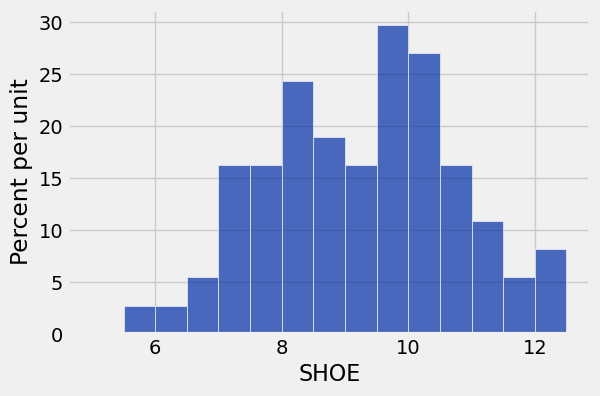

In [8]:
# histogram for the shoe size of the student population
students.hist("SHOE", bins=np.arange(5, 13, 0.5))

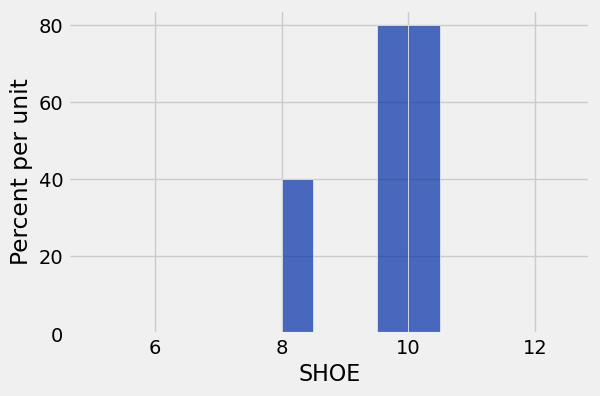

In [9]:
students.sample(5).hist("SHOE", bins=np.arange(5, 13, 0.5))

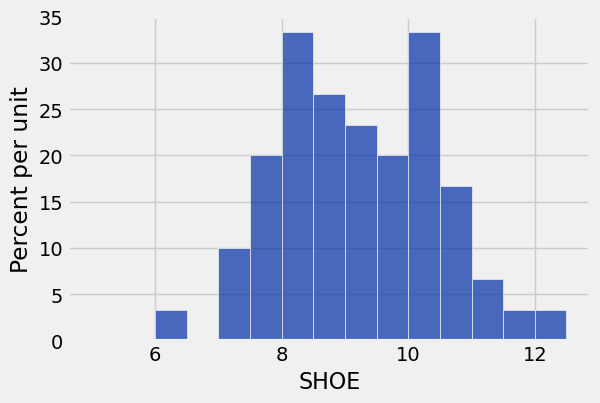

In [10]:
# let's play with sample size
students.sample(60).hist("SHOE", bins=np.arange(5, 13, 0.5))

#### Example 2: Dow Jones Index

In [11]:
djia = Table().read_table("djia.csv")
djia.show(5)

Price,Close,High,Low,Open,Volume
8/16/21,35625.4,35631.2,35231.9,35490.8,292590000
8/17/21,35343.3,35500,35120.3,35500,309410000
8/18/21,34960.7,35356.8,34943.4,35310.2,289800000
8/19/21,34894.1,34997.8,34690.2,34874.7,333550000
8/20/21,35120.1,35177.3,34867.1,34918,269320000


In [12]:
(djia.column("Close").max(), djia.column("Close").min())

(54349.121090000001, 28725.509770000001)

In [13]:
djia.num_rows

1255

##### DJIA 5-year records histogram

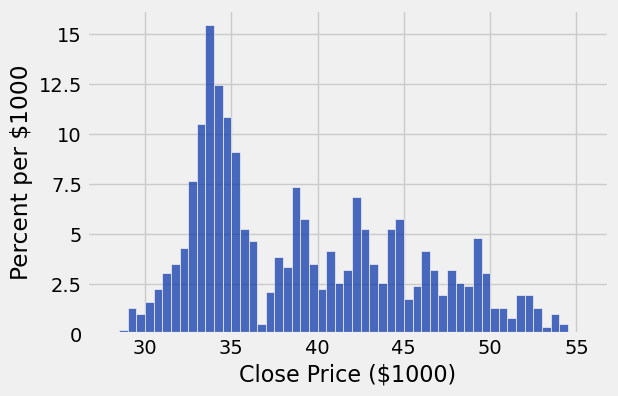

In [14]:
close_tbl = Table().with_columns("Close Price", np.round(djia.column("Close") / 1000, decimals=2))
close_tbl.hist("Close Price", bins=np.arange(28, 56, 0.5), unit="$1000")

In [15]:
close_tbl.num_rows

1255

##### Sampling from Population: DJIA 5-year records histogram

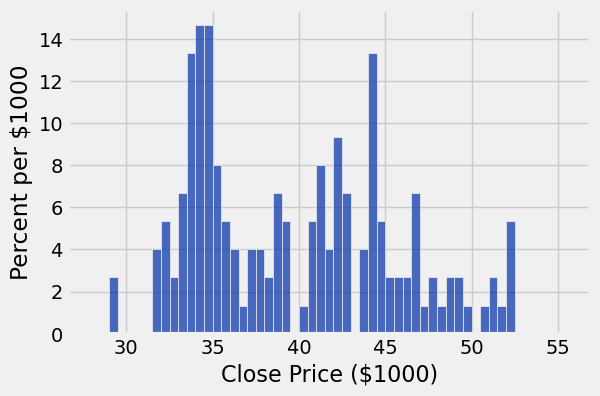

In [16]:
close_tbl.sample(150).hist("Close Price", bins=np.arange(28, 56, 0.5), unit="$1000")

### Sampling Distribution of Means (Statistic)

Consider a population that is made of 3 values: 1, 3, 5. How many samples of 2 are possible if it is taken with replacement? List these samples. 

The sampling strategy that allows all samples to be taken with the same chance is called *Simple Random Sampling* (SRS)

What are all the possible sample means based on these samples? 

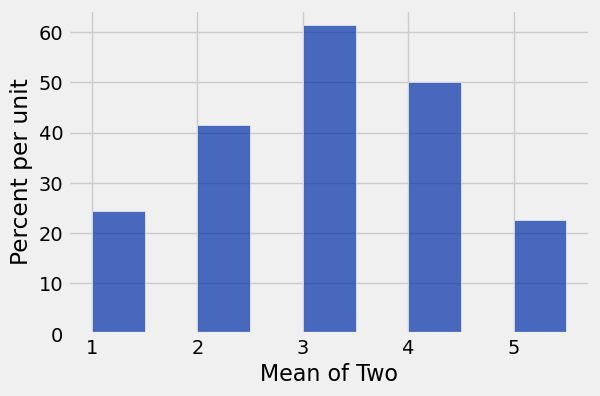

In [17]:
# let's simulate it

population = make_array(1, 3, 5)
sample_size = 2
repeats = 1000
results = make_array()
for i in np.arange(repeats):
    sample = np.random.choice(population, sample_size)
    statistic = np.average(sample)
    results = np.append(results, statistic)

#(results.max(), results.min())

Table().with_column('Mean of Two', results).hist(bins = np.arange(1, 6, 0.5))

If we take the mean of all these sample means, what will it be? Compare your result with the simulation. 

### Sampling from Tables 

By treating the student data as the population, we draw many samples of 2 and compute the sample mean from each sample. 

In [18]:
n = 2
iter = 10000
results = make_array()
for i in np.arange(iter):
    statistic = np.average(students.sample(n).column('HEIGHT'))
    results = np.append(results, statistic)

results

array([ 67.5,  71. ,  68. , ...,  71.5,  69.5,  72. ])

To be able to vary the sample size and the variable, we use the following function to sample from the student data. 

In [19]:
def sampling_distribution(sample_size, col):
    repeats = 10000
    results = make_array()
    for i in np.arange(repeats):
        statistic = np.average(students.sample(sample_size).column(col))
        results = np.append(results, statistic)
    return results

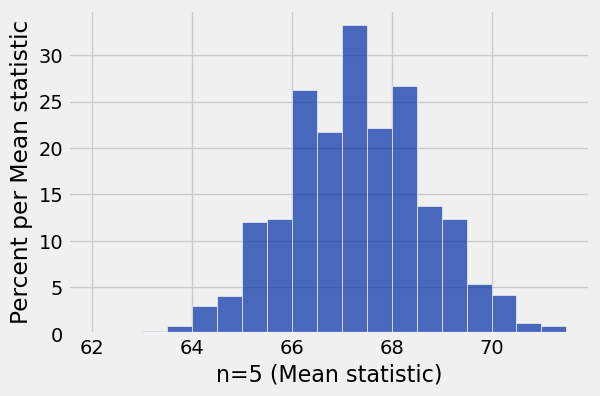

In [20]:
sample_5 = sampling_distribution(5, 'HEIGHT')
Table().with_columns('n=5', sample_5).hist(bins=np.arange(62, 72, 0.5), unit="Mean statistic")

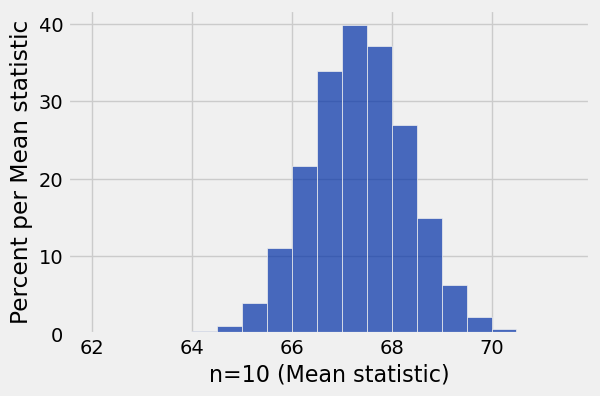

In [21]:
sample_10 = sampling_distribution(10, 'HEIGHT')
Table().with_columns('n=10', sample_10).hist(bins=np.arange(62, 72, 0.5), unit="Mean statistic")

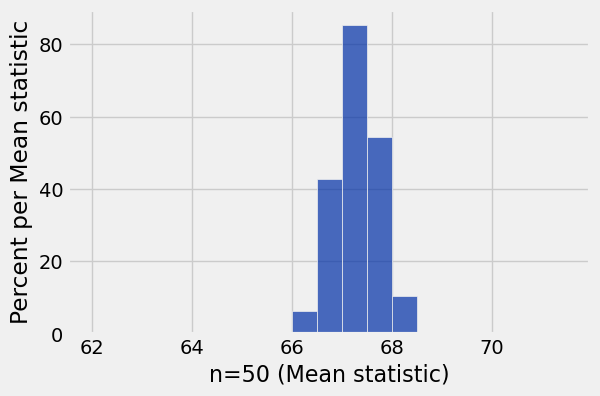

In [22]:
sample_50 = sampling_distribution(50, 'HEIGHT')
Table().with_columns('n=50', sample_50).hist(bins=np.arange(62, 72, 0.5), unit="Mean statistic")

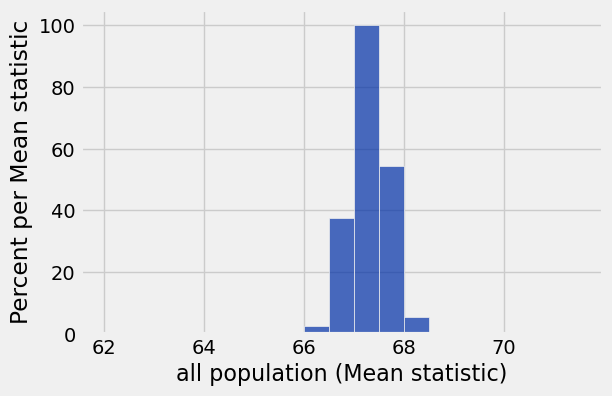

In [23]:
sample_all = sampling_distribution(students.num_rows, 'HEIGHT')
Table().with_columns('all population', sample_all).hist(bins=np.arange(62, 72, 0.5), unit="Mean statistic")

In [24]:
sampling_distributions = Table().with_columns('n=5', sample_5, 'n=10', sample_10, 'n=50', sample_50, 'all population', sample_all)

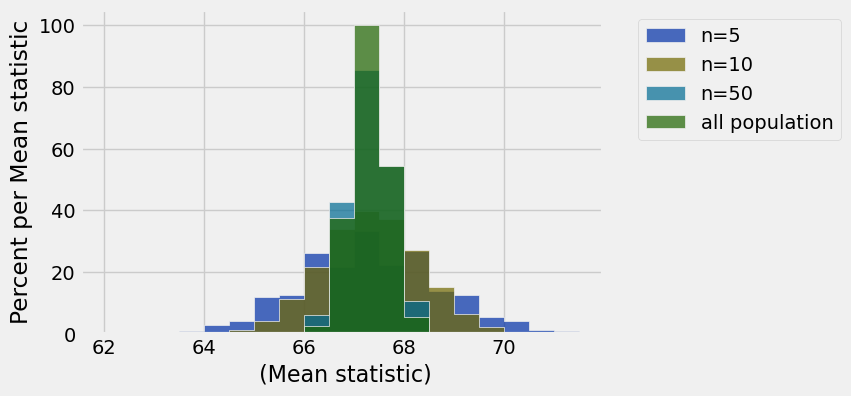

In [25]:
sampling_distributions.hist(bins = np.arange(62, 72, 0.5), unit="Mean statistic")

### Swain v.s. Alabama

The lecture cites the Supreme Court case of [Swain v.s Alabama (1965)](https://supreme.justia.com/cases/federal/us/380/202/). Instead of using `np.random.choice`, the datascience package defines the `sample_proportion` function to simultaneously draw a sample and use it to calculate sample proportions. For example, assuming that 26% of the eligible jurors are black, then the follow code simulates one sample of 100 jurors, and returns an array that contains `(proportion_of_black_jurors, proportion_of_non-black_jurors)`

In [26]:
weights = make_array(0.26, 0.74)
sample_proportions(100, weights)

array([ 0.17,  0.83])

In [27]:
# you can use np.random.choice to accomplish the same thing as sample_proportions, but it takes more work
random_binary = np.random.choice(np.arange(len(weights)), 100, p = weights)
percent_zeros = np.count_nonzero(random_binary == 0) / 100
percent_zeros, 1 - percent_zeros

(0.23999999999999999, 0.76000000000000001)

Based on the `sample_proportions` function, we can generate the sampling distribution of the proportion of black jurors for all jury panels of 100. 

In [28]:
def sampling_distribution_black(n, prop):
    results = [] 
    proportions = make_array(prop, 1-prop)   
    for i in np.arange(100000):
        results = np.append(results, sample_proportions(n, proportions).item(0)*100)
    return results

We can simulate 100,000 jury panels by calling this function:

7

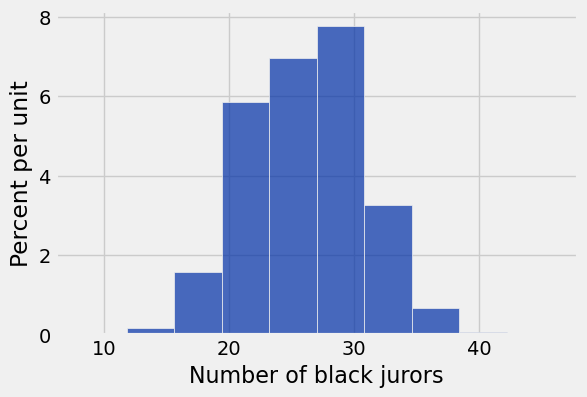

In [29]:
results = sampling_distribution_black(100, 0.26)
Table().with_column('Number of black jurors', results).hist()
np.count_nonzero(results < 10)

### California Lunear New Year Scratchers 

Each year the state of Clifornia issues a $1 instant scratcher. The player will need to match 3 like numbers in the "PLAY AREA" to win that prize. 

- [Year of the Horse Scratcher](https://www.calottery.com/en/scratchers/$1/year-of-the-horse-1706#section-content-2-3)

We are interested in how the numbers on the tickets are generated. 


In [30]:
# this is a hypothetical model of the numbers used in generating the tickets 
# Is this sampling with or without replacement? 
prize_list = make_array(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
np.random.choice(prize_list, 6)

array([70, 20, 30, 50, 80, 90])

In [31]:
# 10000 tickets, 2095 matches/wins

scratchers_observed = Table.read_table("scratcher_winning_uf.csv")
scratchers_observed.show(5)

Prize
70
80
10
10
10


In [32]:
# overall wins over 10000 tickets
scratchers_observed.num_rows / 10000

0.2095

In [33]:
# proportion of winning prizes over 10000 tickets
scratchers_observed.group("Prize")

Prize,count
10,981
20,158
30,162
40,135
50,160
60,162
70,149
80,144
90,21
100,23


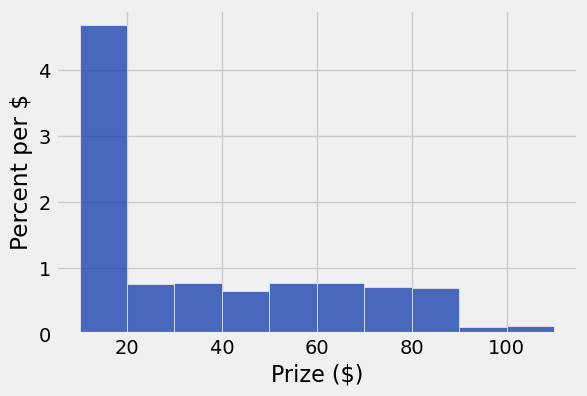

In [34]:
# visualize on a histogram
bin_size = np.arange(10, 111, 10)
scratchers_observed.hist("Prize", bins=bin_size, unit="$")

What is the chance of buying a winning ticket? Although it's possible to solve this probability problem by using counting techniques, it is much easier to just generate a lot of tickets and see how many will win.

The prizes are \\$10, \\$20, \\$30, \\$40, \\$50, \\$60, \\$70, \\$80, \\$90, \\$100. Six prizes will be randomly drawn for the prize list to create a ticket. When a prize appears on a ticket 3 times or more, win the prize.

For example, 

Ticket 1: \\$10, \\$20, \\$60, \\$100, \\$20, \\$20  --> win \\$20

Ticket 2: \\$40, \\$10, \\$40, \\$40, \\$80, \\$60  --> win \\$40

Ticket 3: \\$100, \\$10, \\$40, \\$10, \\$10, \\$10  --> win \\$10

Ticket 4: \\$10, \\$10, \\$60, \\$60, \\$10, \\$60 --> win \\$10 and \\$60

We expect the prizes have a equal chance to be printed on the tickets.

So, we can use `np.random.choice()` to simulate the ticket.

In [35]:
# this is a hypothetical model of the numbers used in generating the tickets 
# Is this sampling with or without replacement?

prize_list = make_array(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
prize_list

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100])

In [36]:
# each price in the prize list has equal chance to be printed on a ticket

np.random.choice(prize_list, 10)

array([50, 80, 20, 80, 10, 90, 50, 50, 20, 10])

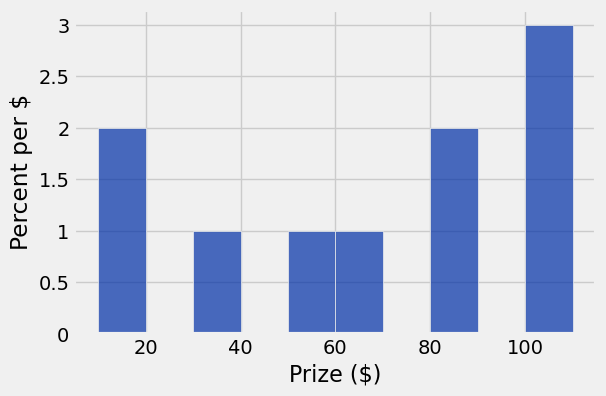

In [41]:
# visualize the result on a histogram
prize_chance = Table().with_columns("Prize", np.random.choice(prize_list, 10))
prize_chance.hist("Prize", bins=np.arange(10, 111, 10), unit="$")

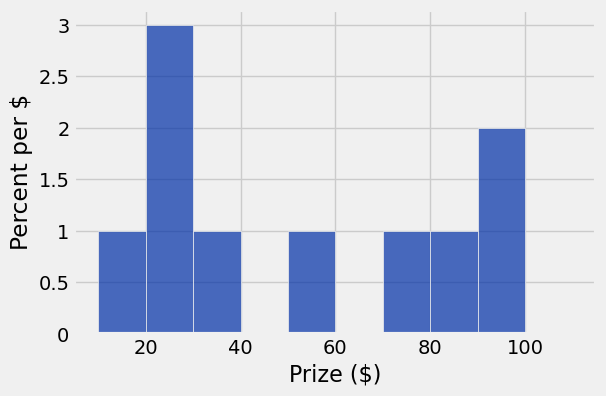

In [42]:
# let's define a function to sample it many times

def prize_chance_sampling(repeats, prize_list, prize_num):
    samples = make_array()
    for t in np.arange(repeats):
        samples = np.append(samples, np.random.choice(prize_list, prize_num)) # with replacement
    return samples

prize_list = make_array(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
prizes = prize_chance_sampling(1, prize_list, 10) # more samples, easier to see the equal chance 
prize_chance = Table().with_columns("Prize", prizes)
prize_chance.hist("Prize", bins=np.arange(10, 111, 10), unit="$")

In [43]:
prize_chance.group("Prize")

Prize,count
10,1
20,3
30,1
50,1
70,1
80,1
90,2


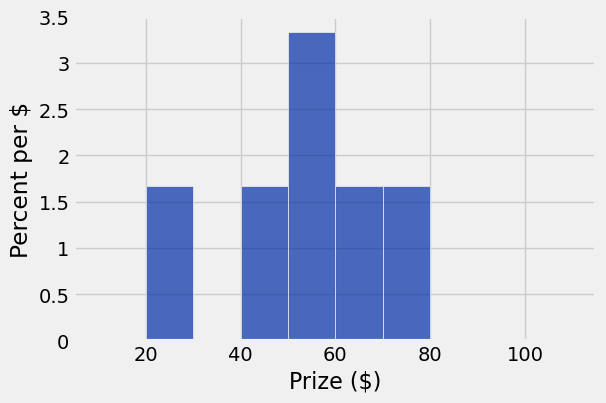

In [44]:
# sample the tickets
#np.random.choice(prize_list, 6)

prize_list = make_array(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
prizes = prize_chance_sampling(1, prize_list, 6) # more samples, easier to see the equal chance 
prize_chance = Table().with_columns("Prize", prizes)
prize_chance.hist("Prize", bins=np.arange(10, 111, 10), unit="$")

In [45]:
prize_chance.group("Prize")

Prize,count
20,1
40,1
50,2
60,1
70,1


In [46]:
# scratcher tickets generator

def generate_scratchers(ticket_num, prize_list, prize_num):
    winning_prizes = make_array()
    for i in np.arange(ticket_num):
        ticket = np.random.choice(prize_list, prize_num)
        for prize in prize_list:
            # add the logics for winning
            number_matches = np.count_nonzero(ticket == prize)
            if number_matches >= 3:
                winning_prizes = np.append(winning_prizes, prize)
            if number_matches > 3:
                break
    return winning_prizes

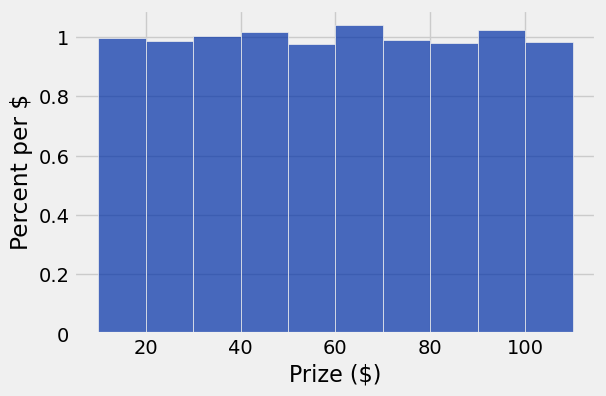

In [47]:
# let's generate a lot of tickets

prize_list = make_array(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
prizes = generate_scratchers(100000, prize_list, 6) # more tickets generated, more probability to win, increase the ticket number and observe
scratchers_random_sampled = Table().with_columns("Prize", prizes)
#scratchers_random_sampled.group("Prize")
scratchers_random_sampled.hist("Prize", bins=np.arange(10, 111, 10), unit="$")

## Assessing a Model Using `sample_proportion()` - Lecture 17 

In [48]:
weights = make_array(0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10)
sample_proportions(100, weights)

array([ 0.12,  0.17,  0.08,  0.06,  0.1 ,  0.09,  0.05,  0.05,  0.15,  0.13])

In [49]:
def sampling_distribution_winning_100(repeats, size, model):
    results = make_array()  
    for i in np.arange(repeats):
        results = np.append(results, sample_proportions(size, model).item(9))
    return results

In [50]:
model = make_array(0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10)
results = sampling_distribution_winning_100(100, 100, model)
results
#Table().with_column("Winning $100", results)#.hist("Winning $100", bins=np.arange(10, 111, 10))
#np.count_nonzero(results >= 0.10)

array([ 0.07,  0.2 ,  0.13,  0.09,  0.07,  0.12,  0.13,  0.18,  0.07,
        0.07,  0.06,  0.1 ,  0.13,  0.1 ,  0.12,  0.16,  0.15,  0.09,
        0.1 ,  0.16,  0.08,  0.11,  0.13,  0.09,  0.04,  0.15,  0.1 ,
        0.05,  0.09,  0.11,  0.08,  0.14,  0.08,  0.09,  0.06,  0.11,
        0.09,  0.14,  0.14,  0.12,  0.07,  0.07,  0.07,  0.09,  0.09,
        0.07,  0.06,  0.09,  0.06,  0.15,  0.16,  0.15,  0.1 ,  0.07,
        0.05,  0.13,  0.08,  0.1 ,  0.09,  0.09,  0.13,  0.06,  0.15,
        0.09,  0.09,  0.11,  0.14,  0.15,  0.08,  0.04,  0.11,  0.1 ,
        0.11,  0.06,  0.07,  0.07,  0.05,  0.06,  0.08,  0.09,  0.06,
        0.06,  0.03,  0.08,  0.08,  0.12,  0.1 ,  0.1 ,  0.12,  0.08,
        0.12,  0.08,  0.11,  0.14,  0.07,  0.08,  0.08,  0.1 ,  0.06,  0.1 ])

Of course, we do not know the weights of the prizes. But this example illustrates that we must use a `model` in order to simulate/predict what the lottery tickets may look like. If we discover that the $888 prize occurrs much less frequently than what's predicted by our model, then this wil count as evidence against our model. In statistics, this line of reasoning is called *model selection*, or *hypothesis testing*. 

In [75]:
# you can use np.random.choice to accomplish the same thing as sample_proportions, but it takes more work
model = make_array(0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10)
random_binary = np.random.choice(np.arange(len(model)), 100, p=model)
percent_zeros = np.count_nonzero(random_binary == 0) / 100
percent_zeros, 1 - percent_zeros

(0.14000000000000001, 0.85999999999999999)